<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 2 &middot; XGBoost & Random Forest</h4>
<h1 align="center">XGBoost &mdash; Pima Indians Diabetes</h1>
<p align="center"><i>Looking before modeling: what the cleaned data actually shows us</i></p>

---

## The data drives the model, not the other way around

It is tempting to treat exploratory data analysis (EDA) as an optional warm-up before "the
real work" of training a model. It is not optional, and it is not warm-up -- it **is** part
of the real work. No boosting algorithm, however powerful, can be trusted on features you
have not personally inspected. XGBoost will fit whatever numbers you hand it, without
complaint and without judgment.

We saw exactly why this matters in `00_dataset_and_impurity.ipynb`. If we had skipped that
notebook and trained directly on `diabetes_raw.csv`, XGBoost would have silently learned that
"0 BMI" and "0 mg/dL glucose" are ordinary, valid values worth splitting on -- because from
the model's point of view, a number is a number. It has no concept that those particular
zeros are lies. The tree would build splits like `BMI < 0.5` treating a data-entry gap as if
it were a real, informative measurement of an emaciated patient, and every downstream
prediction, feature-importance ranking, and SHAP explanation would inherit that nonsense.

This notebook exists to show, visually, what fixing that gap actually bought us -- and to look
at the cleaned data properly before we do anything else with it.

> **Rule of thumb:** if you cannot explain, in one sentence, why a value in your data is what
> it is, you are not ready to model that column.

## Load the cleaned dataset

We use `diabetes_clean.csv`, produced at the end of the previous notebook (sentinel zeros
converted to `NaN`, then imputed with the outcome-grouped median). We also reload the raw
data purely for side-by-side "before" comparisons in the histograms below -- the raw data is
never used for anything past visual contrast.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("data/diabetes_clean.csv")
df_raw = pd.read_csv("data/diabetes_raw.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 1. Histograms: the zero-spike, before and after

For `Glucose`, `BMI`, and `Insulin`, we plot the raw (pre-imputation) distribution next to the
cleaned one. In the raw version, watch for an artificial spike stacked at exactly 0 -- that
spike is not a cluster of real patients with impossible readings, it is every missing record
piling up at a single, wrong value. In the cleaned version, that mass has been redistributed
to the class-conditional median, and the rest of the (biologically plausible) distribution
shape is preserved.

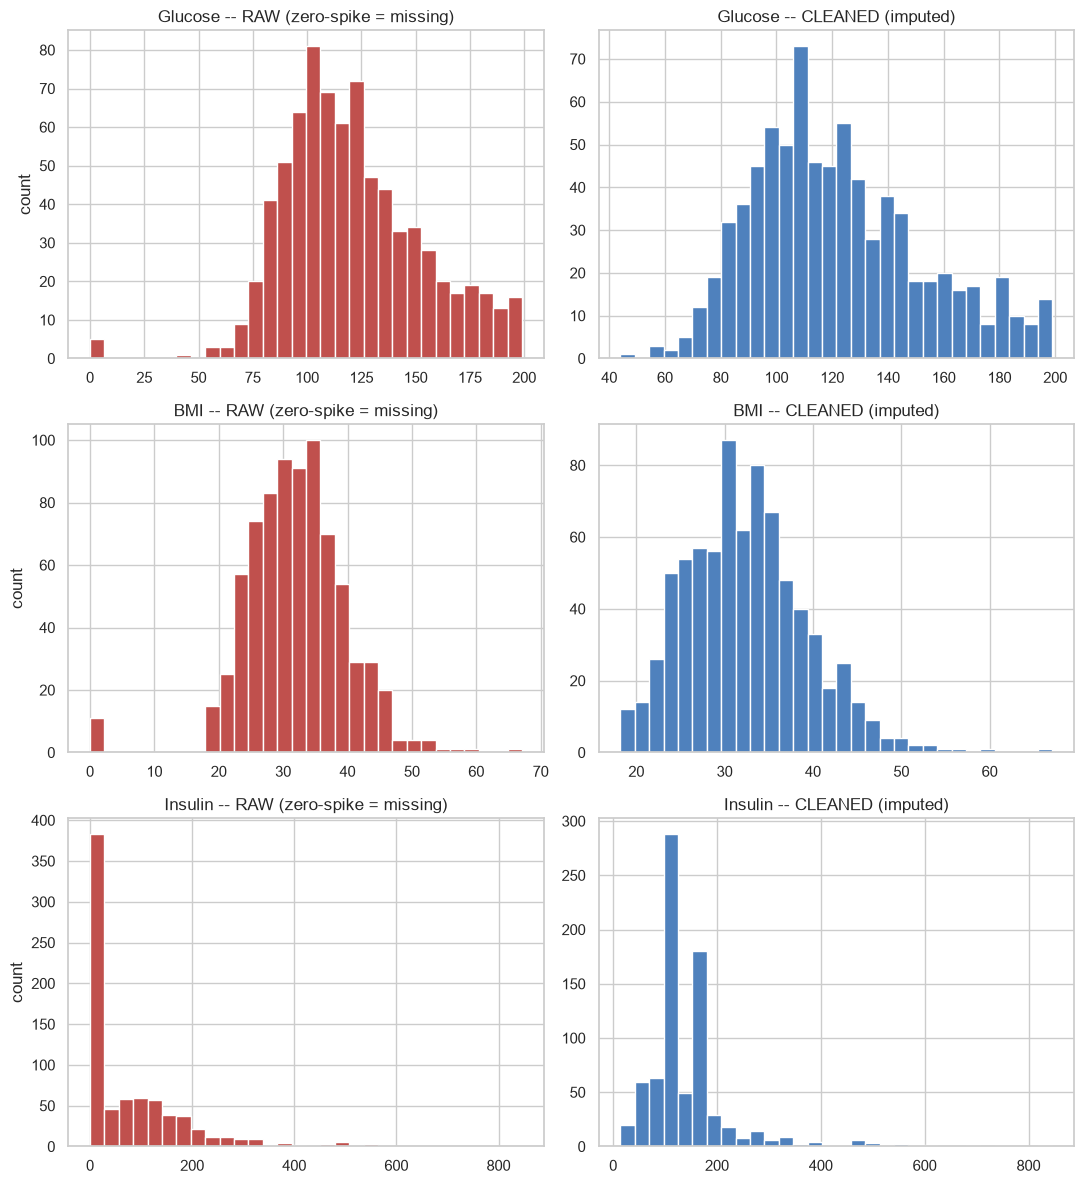

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(11, 12))
cols = ["Glucose", "BMI", "Insulin"]

for i, col in enumerate(cols):
    axes[i, 0].hist(df_raw[col], bins=30, color="#c0504d", edgecolor="white")
    axes[i, 0].set_title(f"{col} -- RAW (zero-spike = missing)")
    axes[i, 0].set_ylabel("count")

    axes[i, 1].hist(df[col], bins=30, color="#4f81bd", edgecolor="white")
    axes[i, 1].set_title(f"{col} -- CLEANED (imputed)")

plt.tight_layout()
plt.show()

`Insulin` shows the most dramatic change: the raw histogram is dominated by a tall bar at 0
that dwarfs every real reading next to it, which would have badly distorted any splits an
untrained eye -- or an untrained model -- might draw near the low end of the range. Once
imputed, `Insulin` looks like a plausible right-skewed clinical measurement, which is what it
actually is.

## 2. Pairplot: joint relationships, colored by outcome

A pairplot lets us see pairwise relationships between four of the most clinically relevant
features -- `Glucose`, `BMI`, `Age`, `Insulin` -- simultaneously, with points colored by
`Outcome`. Diagonal panels show each feature's marginal distribution split by class.

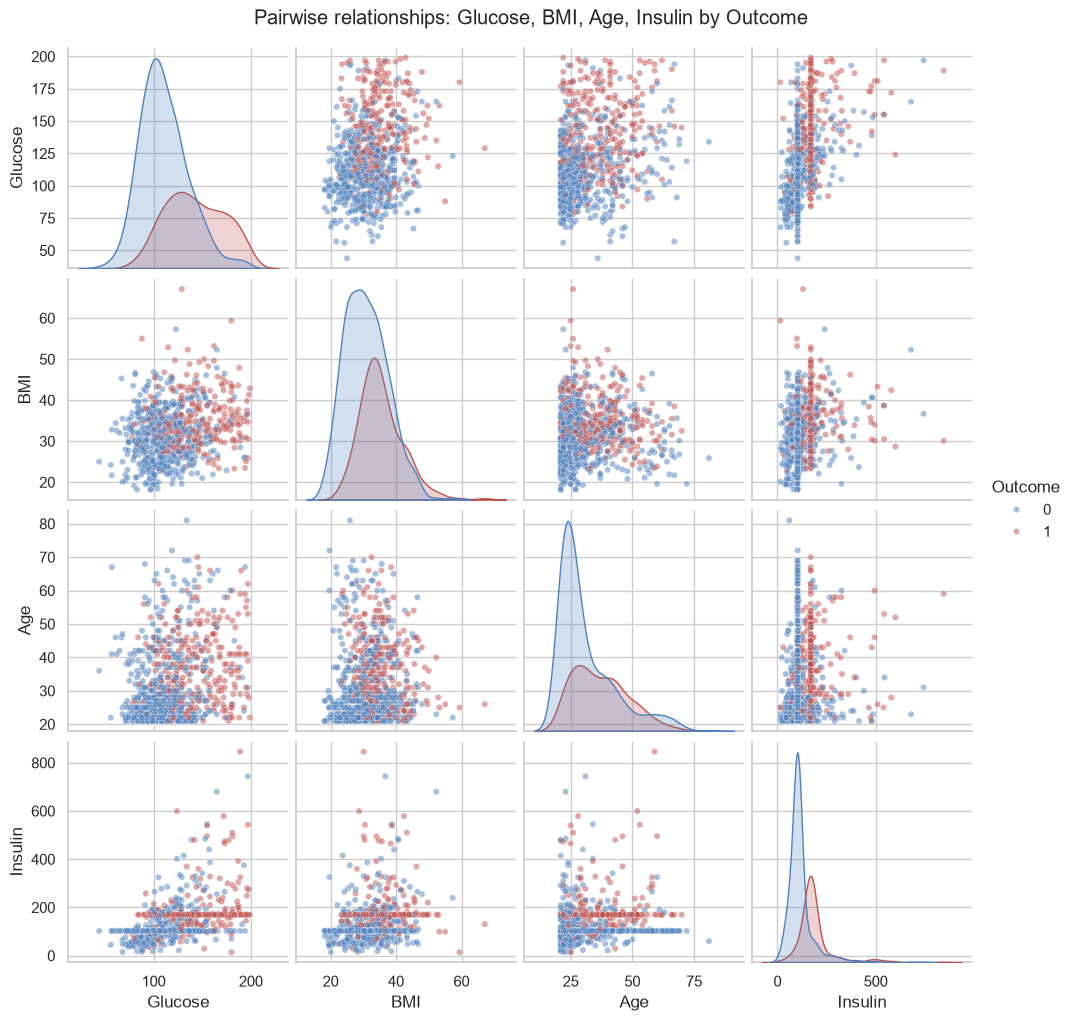

In [4]:
pairplot_cols = ["Glucose", "BMI", "Age", "Insulin", "Outcome"]
g = sns.pairplot(
    df[pairplot_cols],
    hue="Outcome",
    palette={0: "#4f81bd", 1: "#c0504d"},
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20},
)
g.fig.suptitle("Pairwise relationships: Glucose, BMI, Age, Insulin by Outcome", y=1.02)
plt.show()

The clearest separation between the two outcome classes shows up along the `Glucose` axis --
diabetic patients (`Outcome = 1`) are visibly shifted toward higher glucose values in nearly
every panel that includes it. `BMI` and `Age` show a milder but still visible shift in the
same direction. `Insulin` is noisier and overlaps more between classes, which foreshadows why
a single feature is rarely enough and why we need a model that can combine several weak
signals -- exactly what boosting is built to do.

## 3. Boxplots: each feature split by outcome

Boxplots give a compact, comparable summary (median, interquartile range, outliers) of every
feature across the two outcome classes in a single grid.

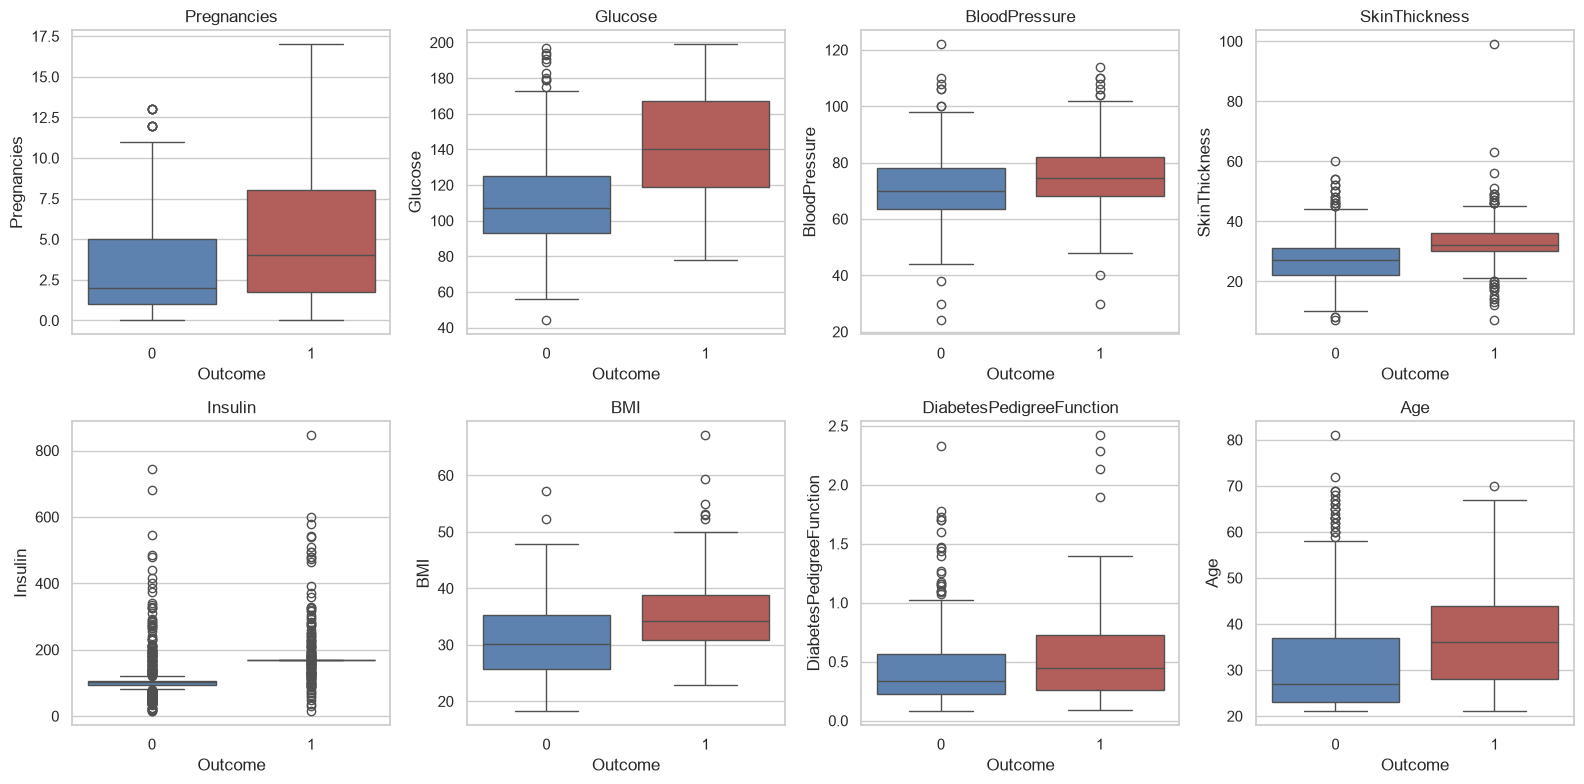

In [5]:
feature_cols = [c for c in df.columns if c != "Outcome"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols):
    sns.boxplot(data=df, x="Outcome", y=col, hue="Outcome", palette={0: "#4f81bd", 1: "#c0504d"}, legend=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

`Glucose`, `BMI`, and `Age` show the clearest median shift between the two boxes -- consistent
with the pairplot above. `Pregnancies` and `DiabetesPedigreeFunction` shift more modestly, and
`BloodPressure` barely shifts at all, suggesting it will carry comparatively little
standalone predictive weight (though it may still contribute through interactions a tree-based
model can pick up on).

## 4. Correlation heatmap

The heatmap below quantifies pairwise linear correlation across every numeric column,
including the target. This is a useful first pass for spotting both **redundant features**
(two columns highly correlated with each other, which a tree model handles gracefully but is
still worth knowing about) and **which features correlate most with `Outcome`** -- our
first-order guess at what will end up mattering most to the model.

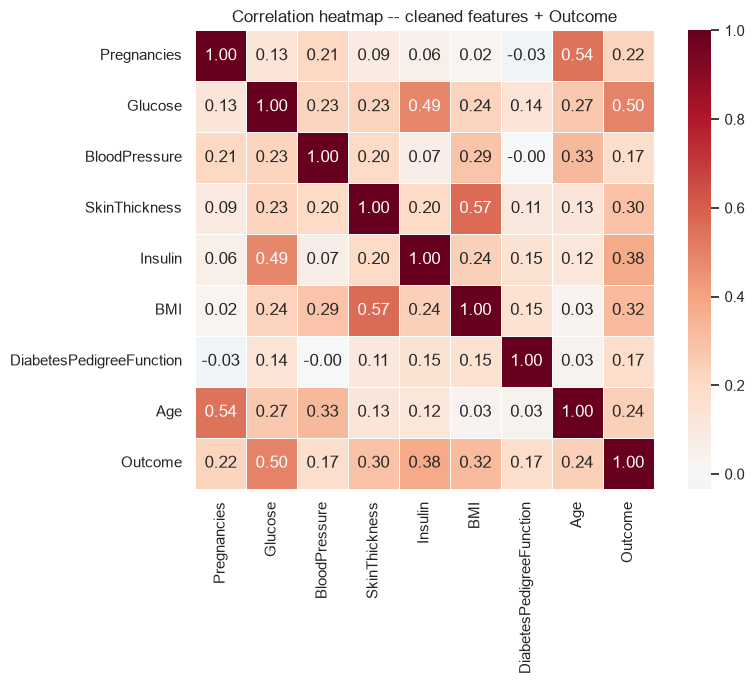

In [6]:
corr = df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5)
plt.title("Correlation heatmap -- cleaned features + Outcome")
plt.tight_layout()
plt.show()

In [7]:
corr["Outcome"].drop("Outcome").sort_values(ascending=False)

Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64

`Glucose` is the single feature most correlated with `Outcome`, followed by `BMI`, `Age`,
and `Pregnancies`. This lines up exactly with the visual evidence from the pairplot and
boxplots above -- three independent views of the data are all pointing at the same handful of
features as the strongest signals.

## 5. Interactive scatter (Plotly): Glucose vs. BMI

A static scatter can only show so much at once. This interactive Plotly view plots `Glucose`
against `BMI`, colors points by `Outcome`, and sizes them by `Age`, so three additional
dimensions of context are all visible in one figure. Hover over any point in a live kernel to
inspect the exact values.

In [8]:
fig = px.scatter(
    df,
    x="Glucose",
    y="BMI",
    color=df["Outcome"].map({0: "Non-diabetic", 1: "Diabetic"}),
    size="Age",
    size_max=15,
    opacity=0.7,
    color_discrete_map={"Non-diabetic": "#4f81bd", "Diabetic": "#c0504d"},
    title="Glucose vs. BMI, colored by Outcome, sized by Age",
    labels={"color": "Outcome"},
)
fig.update_layout(template="plotly_white")
fig.show()

The diabetic cluster (red) leans visibly toward the upper-right of this plot -- higher
glucose *and* higher BMI together -- and toward larger point sizes, i.e. older patients. No
single one of these three variables cleanly separates the classes on its own, but together
they carve out a region where diabetes risk is clearly elevated. This kind of combined,
non-linear region is exactly what a tree-based ensemble like XGBoost is good at carving out
automatically, without us having to hand-engineer the interaction.

## Summary

- Fixing the disguised-missing zeros (notebook 00) visibly removed artificial spikes from the
  `Glucose`, `BMI`, and `Insulin` distributions -- the cleaned data now looks like real
  clinical measurements instead of measurements-plus-data-entry-artifacts.
- `Glucose`, `BMI`, and `Age` consistently emerge as the features most associated with
  `Outcome` across four independent views: pairplot, boxplots, correlation heatmap, and the
  interactive scatter.
- The Glucose x BMI x Age region in the scatter plot shows the classes overlapping in a
  non-linear way that no single feature fully explains -- a strong argument for a model
  capable of learning interactions, which is exactly where we're headed next.
- Next: `02_data_processing.ipynb`, where we redo the imputation with proper train/test
  discipline and prepare the final modeling-ready splits.